# **DataVine Analytics**

### Scenario
As a junior data scientist at DataVine Analytics, we've been assigned to work with a boutique consulting group that specializes in diverse industry applications of machine learning. Our team serves clients across several sectors, and We've been tasked with developing prototype machine learning solutions using standardized datasets that mirror real-world problems.

Our supervisor has outlined three specific client projects that will test your ability to implement classification, recommendation, and clustering techniques while applying dimensionality reduction and hyper-parameter tuning, this lab will focus on:

## **Regional Crime Pattern Analysis (USArrests Dataset)**
A public policy research firm requires a data-driven approach to identify patterns in crime statistics across different regions.

Apply clustering techniques (both K-Means and Gaussian Mixture Models) to discover natural groupings in crime data, using feature selection and dimensionality reduction to focus on the most relevant patterns.

## Step 1: Exploratory data analysis

In this step we will be focusing on understanding the structure, quality, and characteristics of the crime data before preprocessing and applying K-Means & Gaussian Mixture Model (GMM) clustering.

##### 1.1 Dataset Structure and Accessibility

After loading we will be inspecting the dataset's dimensions, column names, data types, and first few records. This helps in understanding what information is available and ensure the data has been loaded correctly before proceeding with data quality checks and further analysis.

In [32]:
# IMPORTS

# Basic data manipulation
import numpy as np
import pandas as pd


# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Data preprocessing
from sklearn.preprocessing import StandardScaler


# Clustering algorithms
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture


# Dimensionality reduction
from sklearn.decomposition import PCA


# Clustering evaluation
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [33]:
# load the data

# Load the USArrests dataset from the CSV file
us_arrests = pd.read_csv("USArrests.csv")

In [34]:
# Database dimensions
us_arrests.shape

(50, 5)

In [35]:
# Display all column names
us_arrests.columns

Index(['Murder', 'Assault', 'UrbanPop', 'Rape', 'State'], dtype='object')

In [36]:
# Display the first 5 rows of the dataset
us_arrests.head()

,Murder,Assault,UrbanPop,Rape,State
0,13.2,236,58,21.2,Alabama
1,10.0,263,48,44.5,Alaska
2,8.1,294,80,31.0,Arizona
3,8.8,190,50,19.5,Arkansas
4,9.0,276,91,40.6,California


In [37]:
# Display the last 5 rows of the dataset
us_arrests.tail()

,Murder,Assault,UrbanPop,Rape,State
45,8.5,156,63,20.7,Virginia
46,4.0,145,73,26.2,Washington
47,5.7,81,39,9.3,West Virginia
48,2.6,53,66,10.8,Wisconsin
49,6.8,161,60,15.6,Wyoming


In [38]:
# Display information about columns, data types, and non-null values
us_arrests.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Murder    50 non-null     float64
 1   Assault   50 non-null     int64  
 2   UrbanPop  50 non-null     int64  
 3   Rape      50 non-null     float64
 4   State     50 non-null     object 
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB


The dataset contains **50 observations and 5 variables**. The four analytical variables (**Murder**, **Assault**, **UrbanPop**, and **Rape**) are correctly stored as numerical data types, while **State** is stored as text. All columns have **50 non-null values**, indicating no missing values at this stage.


### 1.2 Data Quality Checks

Then We will check for missing values, duplicate records, and other inconsistencies that could affect the clustering results. Ensuring  clean and reliable data before applying preprocessing and clustering techniques.

In [39]:
# Check the number of missing values in each column
us_arrests.isnull().sum()

Murder      0
Assault     0
UrbanPop    0
Rape        0
State       0
dtype: int64

In [40]:
# Check whether the dataset contains duplicate rows
us_arrests.duplicated().sum()

np.int64(0)

In [41]:
# Check that each state appears only once
len(us_arrests["State"].unique())

50

The data quality checks show that the **USArrests dataset contains no missing values or duplicate records**, and all 50 states are uniquely represented. Therefore, the dataset is consistent and does not require any cleaning at this stage.


### 1.3 Descriprive statistics

We proceeded to summarize the numerical variables to understand their characteristics. This helps in identifying differences in crime rates across states and determine whether any variables have substantially different scales before clustering.

In [42]:
# Generate descriptive statistics for the numerical variables
us_arrests.describe()

,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


There is a substantial variation across the states. **Assault** has the highest average rate (170.76), while **Murder** averages 7.79 and **Rape** 21.23. **UrbanPop** has an average of 65.54, with values ranging from 32 to 91. The wide ranges and different scales among the variables highlight the need to **standardize the numerical features before clustering**.


### 1.4 Distribution Analysis

Next step is to examine the distribution of each numerical variable. This helps us understand the spread of crime rates, identify skewness, and detect unusually high or low observations that may influence the clustering algorithms.

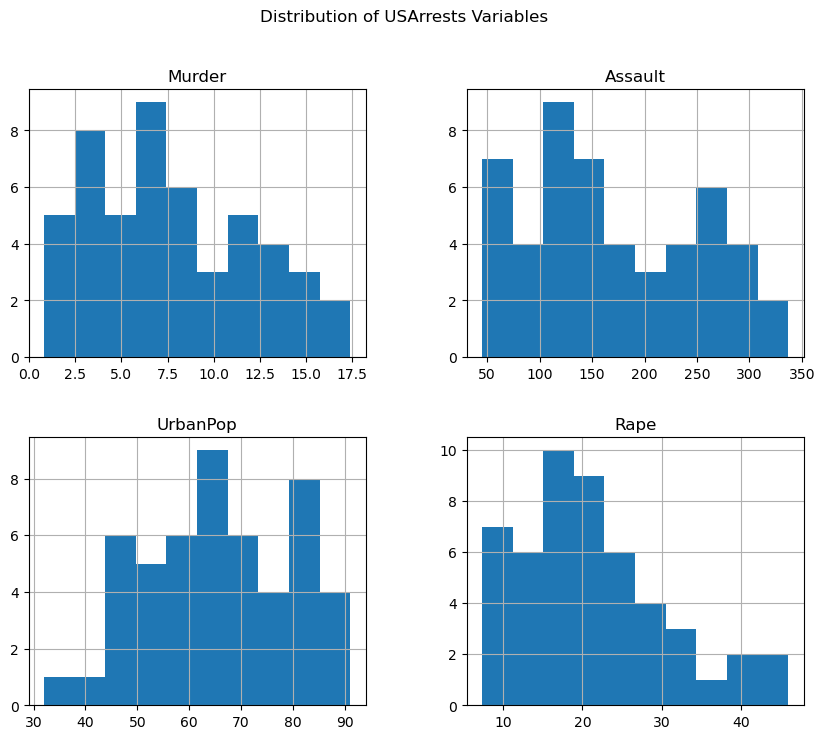

In [43]:
# Create histograms for the numerical variables
us_arrests[["Murder", "Assault", "UrbanPop", "Rape"]].hist(
    figsize=(10, 8),
    bins=10
)

# Add a title to the overall figure
plt.suptitle("Distribution of USArrests Variables")

# Display the plots
plt.show()

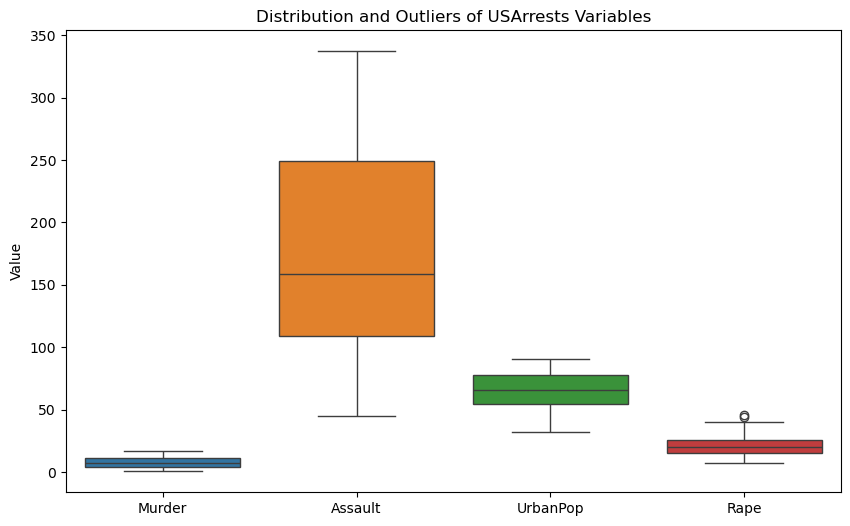

In [44]:
# Create boxplots to visualize the spread and potential outliers
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=us_arrests[["Murder", "Assault", "UrbanPop", "Rape"]]
)

plt.title("Distribution and Outliers of USArrests Variables")
plt.ylabel("Value")
plt.show()

The distributions showed considerable variation across the four variables. **Assault** has the widest spread, while **Murder** and **Rape** show some right-skewness, with a few states having relatively high values. **UrbanPop** is more evenly distributed across its range. **The boxplots** also indicate **potential outliers in Rape**, while the other variables show relatively few extreme observations. These differences in scale and spread, further support the need to **standardize the numerical features before clustering**.


### 1.5 Correlation Analysis

It entails examining the relationships between the numerical variables this will help us determine whether crime variables move together and whether some features provide similar information. This is useful for understanding the underlying crime patterns before selecting the features for clustering.

In [45]:
# Select the numerical variables for correlation analysis
crime_features = ["Murder", "Assault", "UrbanPop", "Rape"]

# Calculate the correlation matrix
correlation_matrix = us_arrests[crime_features].corr()

# Display the correlation matrix
correlation_matrix

,Murder,Assault,UrbanPop,Rape
Murder,1.000000,0.801873,0.069573,0.563579
Assault,0.801873,1.000000,0.258872,0.665241
UrbanPop,0.069573,0.258872,1.000000,0.411341
Rape,0.563579,0.665241,0.411341,1.000000


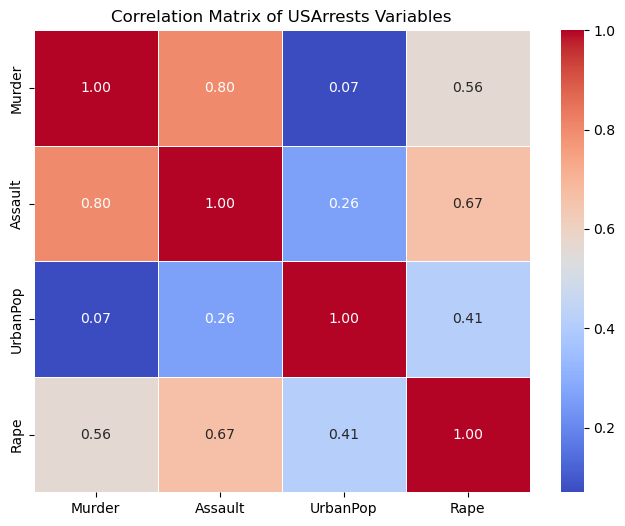

In [46]:
# Create a heatmap to visualize the correlations
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,          # Display correlation values
    cmap="coolwarm",     # Use different shades for positive and negative correlations
    fmt=".2f",           # Display values to 2 decimal places
    linewidths=0.5
)

plt.title("Correlation Matrix of USArrests Variables")
plt.show()

### Correlation interpretation & Feature Selection 

The correlation analysis shows that Murder, Assault, and Rape are positively related, with correlations of 0.80, 0.67, and 0.56 respectively. Although the high correlation between Murder and Assault means they contain some overlapping information, this does not make them unsuitable for clustering. Instead, these relationships suggest that states experiencing higher levels of one type of serious crime often experience higher levels of other serious crimes as well.

We selected Murder, Assault, and Rape because they are all direct measures of crime, which closely matches the project's goal of identifying regional crime patterns. UrbanPop was excluded because it has a particularly weak relationship with Murder (0.07) and Assault (0.26). Therefore, the three selected crime variables provide the most direct representation of the crime patterns we want the clustering algorithms to identify.

## Step 2: Preprocessing 

In this step, we will be preparing the selected crime data so that it is suitable for clustering. First, we will use the three crime-related features identified during EDA: Murder, Assault, and Rape. Then standardize these features so that they are on the same scale and no single variable dominates the clustering process. Finally, we will apply PCA (Principal Component Analysis) to reduce the three standardized features to two principal components, which will make the data easier to visualize while retaining the most important patterns in the crime data.

### 2.1 Feature Selection

We will use the three selected features.

In [47]:
# Select the three crime-related features for clustering
clustering_features = ["Murder", "Assault", "Rape"]

# Create a new DataFrame containing only the selected features
crime_data = us_arrests[clustering_features]

# Display the selected features
crime_data.head()

,Murder,Assault,Rape
0,13.2,236,21.2
1,10.0,263,44.5
2,8.1,294,31.0
3,8.8,190,19.5
4,9.0,276,40.6


## 2.2 Feature Standardization

Now that we have selected the three crime features, we need to standardize them before clustering. This is important because Murder, Assault, and Rape have different numerical ranges and Standardization puts them on a common scale so that each feature contributes fairly to the clustering process.

In [48]:
# Create the StandardScaler object
scaler = StandardScaler()

# Fit the scaler to the selected crime features
# and transform them into standardized values
crime_scaled = scaler.fit_transform(crime_data)

# Convert the standardized array back into a DataFrame
# to feature names are retained
crime_scaled = pd.DataFrame(
    crime_scaled,
    columns=clustering_features
)

# Display the first 5 rows of the standardized data
crime_scaled.head()

# Veryfy standardization 
        # Check the mean of each standardized feature
print("Means:")
print(crime_scaled.mean())

        # Check the standard deviation of each standardized feature
print("\nStandard deviations:")
print(crime_scaled.std())

Means:
Murder    -7.105427e-17
Assault    1.387779e-16
Rape       8.593126e-16
dtype: float64

Standard deviations:
Murder     1.010153
Assault    1.010153
Rape       1.010153
dtype: float64


### 2.3 Dimensionality Reduction Using PCA

After standardization, we will apply Principal Component Analysis (PCA) to reduce the dataset from 3 features to 2 principal components. Thus simplify the data (keeping in check dimentionality) while retaining as much of the important variation as possible.

In [49]:
# Create the PCA object and specify that we want
# to reduce the data to 2 principal components
pca = PCA(n_components=2)

# Fit PCA to the standardized crime data
# and transform the data into two principal components
crime_pca = pca.fit_transform(crime_scaled)

# Convert the PCA results into a DataFrame
# with clear column names
crime_pca = pd.DataFrame(
    crime_pca,
    columns=["PC1", "PC2"]
)

# Display the first 5 rows of the PCA-transformed data
crime_pca.head()

,PC1,PC2
0,1.210191,-0.842277
1,2.332187,1.539434
2,1.518593,0.503363
3,0.177776,-0.328029
4,2.066000,1.285497


In [50]:
# VERIFY THE PREPROCESSED DATASET

# Check the shape of the PCA-transformed dataset
print("PCA dataset shape:", crime_pca.shape)

# Check the column names
print("\nPCA columns:")
print(crime_pca.columns)

# Check for missing values
print("\nMissing values:")
print(crime_pca.isnull().sum())

# Display the first 5 rows
print("\nFirst 5 rows:")
crime_pca.head()

PCA dataset shape: (50, 2)

PCA columns:
Index(['PC1', 'PC2'], dtype='object')

Missing values:
PC1    0
PC2    0
dtype: int64

First 5 rows:


,PC1,PC2
0,1.210191,-0.842277
1,2.332187,1.539434
2,1.518593,0.503363
3,0.177776,-0.328029
4,2.066000,1.285497


The preprocessing check confirms that the dataset contains **50 observations and 2 principal components** (PC1 and PC2), with **no missing values**. Therefore, the data has been successfully standardized and reduced using PCA and is **clustering**.


## Step 3: Model implementation

This step is where**K-Means and Gaussian Mixture Model (GMM)** clustering occurs. First, we will determine the optimal number of clusters using the **Elbow Method for K-Means** and **BIC for GMM**.Then fit both models using their selected number of clusters and compare the resulting regional crime patterns.


#### 3.1 K-Means: Elbow Method
By using the Elbow Method, which compares the inertia (WCSS- Sum of squared distance from the data points to the centroid), for different values of k. The optimal number of clusters is typically found at the point where adding more clusters produces only a small improvement in inertia.

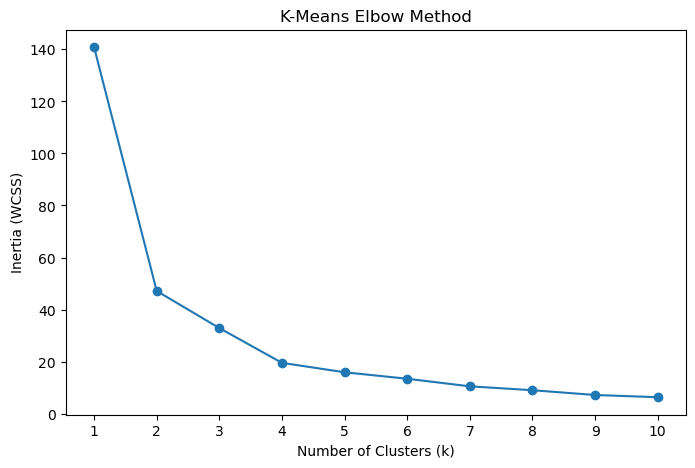

In [51]:
# Create an empty list to store the inertia (WCSS) values
wcss = []

# Test different numbers of clusters from 1 to 10
k_values = range(1, 11)

# Calculate inertia for each value of k
for k in k_values:
    
    # Create the K-Means model
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    # Fit the model using the PCA-transformed data
    kmeans.fit(crime_pca)
    
    # Store the within-cluster sum of squares (inertia)
    wcss.append(kmeans.inertia_)


# Plot the Elbow Method
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("K-Means Elbow Method")

plt.xticks(k_values)
plt.show()

#### 3.2 GMM: Determining the Optimal Number of Clusters

For the Gaussian Mixture Model (GMM), We will be using the Bayesian Information Criterion (BIC) to compare GMM models with different numbers of components. The model with the lowest BIC score provides the best balance between model fit and complexity, helping us choose an appropriate number of crime clusters.

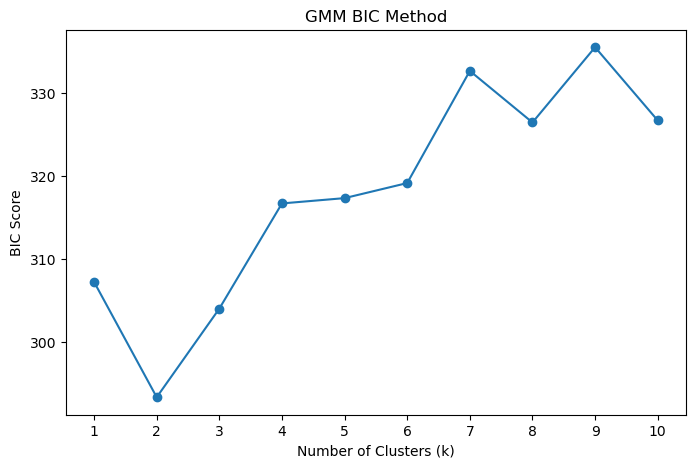

In [52]:
# Create an empty list to store the BIC scores
bic_scores = []

# Test different numbers of components from 1 to 10
k_values = range(1, 11)

# Calculate BIC for each number of components
for k in k_values:
    
    # Create the Gaussian Mixture Model
    gmm = GaussianMixture(
        n_components=k,
        random_state=42,
        n_init=10
    )
    
    # Fit the GMM using the PCA-transformed data
    gmm.fit(crime_pca)
    
    # Calculate and store the BIC score
    bic_scores.append(gmm.bic(crime_pca))

    # Plot the BIC scores

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    bic_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("BIC Score")
plt.title("GMM BIC Method")

plt.xticks(k_values)
plt.show()

#### **Interpretation**
K-Means: The Elbow Method shows a sharp decrease in inertia from 1 to 4 clusters, after which the reduction becomes much smaller. This suggests that 4 clusters is a reasonable choice because adding more clusters provides only limited improvement.

GMM: The BIC reaches its lowest value at 2 clusters. Since lower BIC indicates a better balance between model fit and complexity, 2 components is the optimal choice for the GMM.

### 3.3 Apply K-means & Gmm

In [53]:
# Create the final K-Means model using 4 clusters
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Fit the K-Means model to the PCA-transformed data
kmeans.fit(crime_pca)

# Assign each state to its K-Means cluster
kmeans_labels = kmeans.labels_

# Display the cluster assignments
kmeans_labels

array([1, 2, 2, 3, 2, 2, 0, 3, 1, 1, 0, 0, 1, 3, 0, 3, 3, 1, 0, 1, 3, 2,
       0, 1, 3, 3, 0, 2, 0, 3, 2, 1, 1, 0, 3, 3, 3, 3, 0, 1, 0, 1, 1, 3,
       0, 3, 3, 0, 0, 3], dtype=int32)

In [54]:
# Create the final Gaussian Mixture Model using 2 components
gmm = GaussianMixture(
    n_components=2,
    random_state=42,
    n_init=10
)

# Fit the GMM to the PCA-transformed data
gmm.fit(crime_pca)

# Assign each state to its most likely GMM cluster
gmm_labels = gmm.predict(crime_pca)

# Display the cluster assignments
gmm_labels

array([1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0])

### 3.4 Visualize K-Means and GMM clusters using PCA

We will use the two PCA components to visualize how the states are grouped by K-Means and GMM. Each point represents a state, while the color represents its assigned cluster.

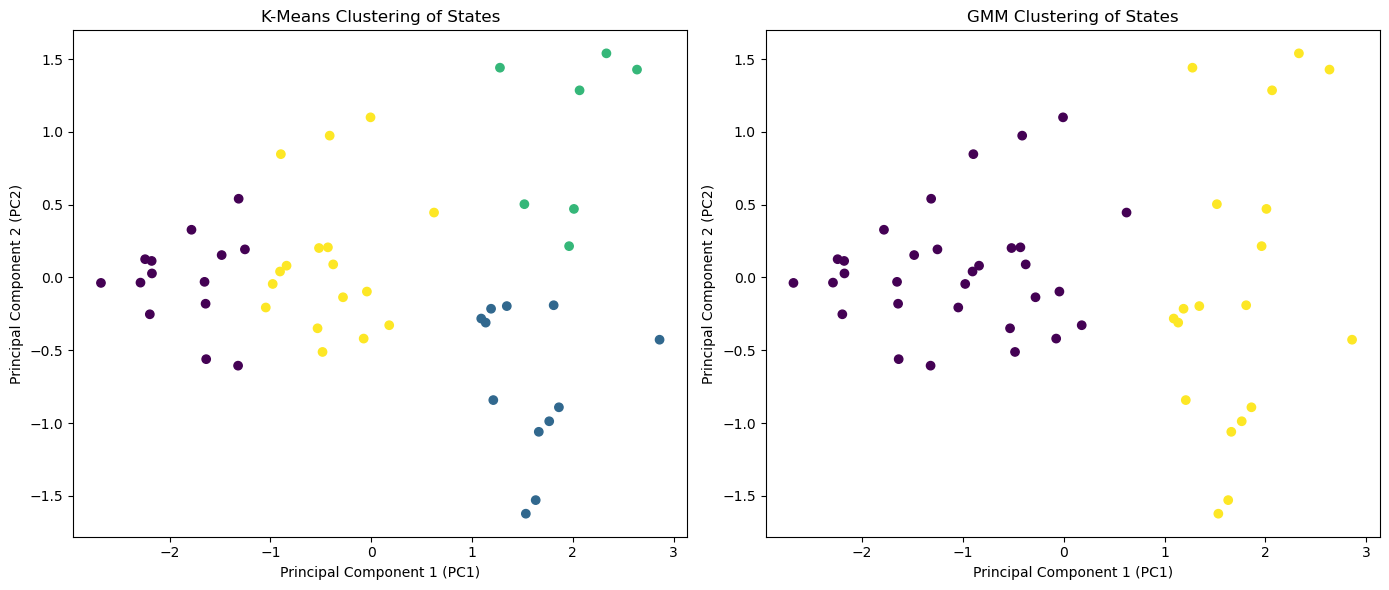

In [55]:
# Create two plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


# K-MEANS CLUSTER VISUALIZATION

# Plot PC1 against PC2
# Each point represents a state
# The color represents its K-Means cluster
axes[0].scatter(
    crime_pca["PC1"],
    crime_pca["PC2"],
    c=kmeans_labels,
    cmap="viridis",
    marker="o"
)

# Add labels to the axes
axes[0].set_xlabel("Principal Component 1 (PC1)")
axes[0].set_ylabel("Principal Component 2 (PC2)")

# Add a title
axes[0].set_title("K-Means Clustering of States")


# GMM CLUSTER VISUALIZATION

# Plot PC1 against PC2
# Each point represents a state
# The color represents its GMM cluster
axes[1].scatter(
    crime_pca["PC1"],
    crime_pca["PC2"],
    c=gmm_labels,
    cmap="viridis",
    marker="o"
)

# Add labels to the axes
axes[1].set_xlabel("Principal Component 1 (PC1)")
axes[1].set_ylabel("Principal Component 2 (PC2)")

# Add a title
axes[1].set_title("GMM Clustering of States")


# Adjust the spacing between the plots
plt.tight_layout()

# Display both plots
plt.show()

The plots show that K-Means separates the states into four crime-pattern clusters, while GMM groups them into two broader clusters. The clusters are mainly separated along PC1 and PC2, indicating differences in the states' overall Murder, Assault, and Rape patterns. K-Means provides more detailed groupings

## Step 4: Evaluation
Evaluation of the quality of the K-Means and GMM clustering results by using the silhouette score, assessing how well the states are separated within their assigned clusters. Also, compare the performance of the two models to determine which provides more meaningful clustering of the crime patterns.

### 4.1 Silhouette Score Evaluation

Evaluate how well-separated and cohesive the K-Means and GMM clusters are.

In [56]:
# Calculate the silhouette score for K-Means
kmeans_silhouette = silhouette_score(
    crime_pca,
    kmeans_labels
)

# Calculate the silhouette score for GMM
gmm_silhouette = silhouette_score(
    crime_pca,
    gmm_labels
)

# Display the results
print('KMeans Silhoutte score', kmeans_silhouette)
print('GMM Silhouttte Score', gmm_silhouette)

KMeans Silhoutte score 0.4643339143418435
GMM Silhouttte Score 0.5609728065820804


The K-Means silhouette score is 0.4643, while the GMM score is 0.5610. Since a higher silhouette score indicates better-defined and more separated clusters, GMM performed better than K-Means on this dataset. This suggests that the two GMM clusters represent the states' crime patterns more clearly than the four K-Means clusters.

### 4.2 Cluster sizes

Examine how the 50 states are distributed across the 4 kmeans and 2 gmm clusters. To helps us determine whether the clusters are reasonably balanced

In [57]:
# Count the number of states assigned to each K-Means cluster
kmeans_cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()

# Count the number of states assigned to each GMM cluster
gmm_cluster_counts = pd.Series(gmm_labels).value_counts().sort_index()

# Display the cluster sizes
print("K-Means Cluster Sizes:")
print(kmeans_cluster_counts)

# Display the cluster sizes
print("GMM Cluster Sizes:")
print(gmm_cluster_counts)

K-Means Cluster Sizes:
0    14
1    12
2     7
3    17
Name: count, dtype: int64
GMM Cluster Sizes:
0    31
1    19
Name: count, dtype: int64


### 4.3 Cluster Summary

| Evaluation         |       K-Means |        GMM |
| ------------------ | ------------: | ---------: |
| Number of clusters |             4 |          2 |
| Silhouette Score   |        0.4643 | **0.5610** |
| Cluster sizes      | 14, 12, 7, 17 |     31, 19 |

GMM performed better than K-Means, achieving a **higher silhouette score (0.5610 vs 0.4643)**, indicating that its clusters are more clearly separated and internally consistent. K-Means provides more detailed grouping with four clusters, while GMM identifies two broader crime-pattern groups. Therefore, **GMM provides the better-defined clustering solution for this dataset**.


## Step 5: Result interpretation

This is where we explain the business/public-policy meaning of the clusters.

For example:

What characterizes each crime cluster?
Which states belong to each cluster?
How do K-Means and GMM differ?
What do the identified regional crime patterns mean for the public policy research firm?


5.4 K-Means vs GMM: Results Comparison
How do the four K-Means groups differ from the two GMM groups?
Why might GMM have produced better-defined clusters based on the silhouette scores?
What does this tell us about the structure of the crime data?
5.5 Public Policy Implications
What do the identified regional crime patterns mean for the public policy research firm?
How could the clusters help identify areas requiring different levels or types of intervention?
How could policymakers use these patterns to support targeted crime-prevention strategies and resource allocation?

### 5.1 K-Means Cluster Characteristics

In this step, we will examine the average Murder, Assault, and Rape rates within each K-Means cluster. This will help us understand what distinguishes each of the four crime-pattern groups.

In [58]:
# Add the K-Means cluster labels to the crime data
kmeans_results = crime_data.copy()
kmeans_results["KMeans_Cluster"] = kmeans_labels

# Calculate the average crime rates for each cluster
kmeans_profile = kmeans_results.groupby("KMeans_Cluster")[
    ["Murder", "Assault", "Rape"]
].mean()

# Display the cluster profiles
kmeans_profile

,Murder,Assault,Rape
KMeans_Cluster,,,
0,3.078571,80.928571,11.800000
1,13.633333,258.166667,23.925000
2,10.100000,261.285714,38.285714
3,6.588235,145.764706,20.076471


5.2 GMM Cluster Characteristics

In this step, we will examine the average Murder, Assault, and Rape rates within each GMM cluster. This will help us understand the crime patterns represented by the two GMM groups and how they differ in their overall crime levels.

In [59]:
#  Add the GMM cluster labels to the crime data
gmm_results = crime_data.copy()
gmm_results["GMM_Cluster"] = gmm_labels

# Calculate the average crime rates for each GMM cluster
gmm_profile = gmm_results.groupby("GMM_Cluster")[
    ["Murder", "Assault", "Rape"]
].mean()

# Display the GMM cluster profiles
gmm_profile

,Murder,Assault,Rape
GMM_Cluster,,,
0,5.003226,116.483871,16.338710
1,12.331579,259.315789,29.215789


K-Means identified Cluster 0 having the lowest crime levels, Cluster 2 have the highest overall crime levels, while Clusters 1 and 3 represent high and moderate crime levels, respectively.

GMM identified that cluster 0 having slower levels of Murder, Assault, and Rape, while Cluster 1 has substantially higher levels across all three crime measures. 

### 5.3 States Within Each Cluster
identify which states belong to each K-Means and GMM cluster. This will make the crime-pattern groups easier to understand and connect the clustering results to specific states.

In [60]:
# Create a copy of the original dataset
clustered_data = us_arrests.copy()

# Add K-Means cluster assignments
clustered_data["KMeans_Cluster"] = kmeans_labels

# Add GMM cluster assignments
clustered_data["GMM_Cluster"] = gmm_labels

In [61]:
# Display the states and their K-Means and GMM assignments
cluster_assignments = clustered_data[
    ["State", "KMeans_Cluster", "GMM_Cluster"]
]

# Display the cluster assignments
cluster_assignments.sort_values(
    ["KMeans_Cluster", "GMM_Cluster"]
)

,State,KMeans_Cluster,GMM_Cluster
6,Connecticut,0,0
10,Hawaii,0,0
11,Idaho,0,0
14,Iowa,0,0
18,Maine,0,0
22,Minnesota,0,0
26,Nebraska,0,0
28,New Hampshire,0,0
33,North Dakota,0,0
38,Rhode Island,0,0


The cluster assignments show which states share similar crime patterns based on Murder, Assault, and Rape.

## 5.4 Public Policy Implications and Recommendations

The clustering analysis provides the public policy research firm with a **data-driven way to identify states with similar crime patterns**. Rather than treating all states as having the same crime situation, the results above show that states can be grouped according to their levels of **Murder, Assault, and Rape**.

### Key findings for policymakers

* **Identify higher-crime states:** GMM identified a higher-crime group of **19 states**, including Alabama, Alaska, Arizona, California, Florida, Georgia, Louisiana, Michigan, Mississippi, Nevada, New Mexico, New York, North Carolina, South Carolina, Tennessee, and Texas. These states may require greater attention when planning crime-prevention initiatives.

* **Identify lower-crime states:** The remaining **31 states** formed the lower-crime GMM group. These states can provide useful comparisons for understanding factors or policies associated with lower levels of reported crime.

* **Target policies according to crime patterns:** K-Means provides a more detailed segmentation. For example, **Alaska, Arizona, California, Colorado, Michigan, Nevada, and New Mexico** form a separate cluster with particularly high Rape levels alongside high Murder and Assault levels. These states may benefit from interventions specifically addressing the crime characteristics that distinguish this group.

* **Avoid a one-size-fits-all approach:** The four K-Means clusters demonstrate that even states classified broadly as higher-crime can have **different combinations of crime levels**. Policymakers can therefore design interventions according to the specific crime profile of each group.

* **Prioritize resource allocation:** The clusters can help policymakers prioritize **funding, law-enforcement resources, prevention programs, victim-support services, and community interventions** toward areas with greater or specific crime burdens.

* **Use similar states for policy comparison:** States within the same cluster have similar crime patterns. Policymakers can compare these states to identify differences in existing policies, prevention strategies, and resource allocation that may help explain variations in crime outcomes.

* **Support regional monitoring:** The clustering framework can be repeated with updated crime data to monitor whether states move between crime-pattern groups over time. This can help the research firm identify **emerging high-risk patterns and evaluate whether interventions are associated with improvements**.

### Overall conclusion

The analysis successfully provides a **data-driven segmentation of US states based on crime patterns**. K-Means offers a more detailed four-group segmentation, while GMM provides a simpler distinction between lower- and higher-crime states and achieved the stronger silhouette score. For the public policy research firm, these results can support **targeted interventions, evidence-based resource allocation, comparison of similar states, and ongoing monitoring of regional crime patterns**.

> **Important:** The clusters identify statistical similarities in the USArrests data; they do not by themselves establish that a particular policy caused higher or lower crime. Further socioeconomic, demographic, and policy data would be needed before making causal policy decisions.
